In [15]:
import numpy as np 
from uncertainties import ufloat
from uncertainties import unumpy as unp
from IPython.display import Latex, HTML, Math, display
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import linregress
import pandas as pd
from scipy import constants as c
from matplotlib.patches import Rectangle
from matplotlib.ticker import MaxNLocator
from sklearn.metrics import r2_score


# zum import von py Dateien
from pathlib import Path
import sys

# Projekt-Root zum importieren von Helper
ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from Helper import Helper 




152.431+/-4.100
[0.09045634 0.00164429]
1.56+/-0.09


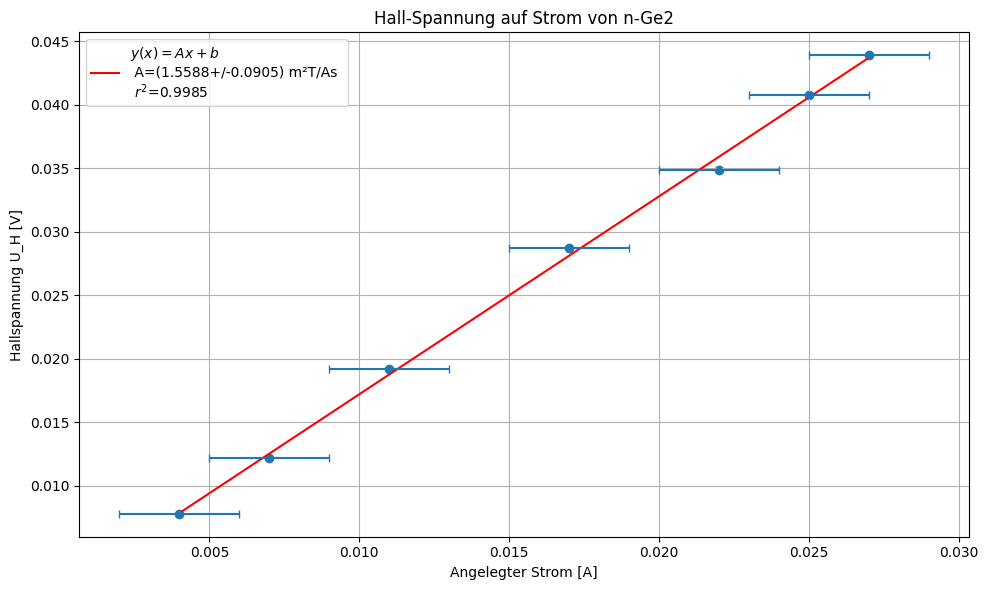

10226.04852+/-654.07714
610353946576713.25000+/-39039377035583.91406
(6.1+/-0.4)e+14


In [16]:
# Hall-Spannung

# known
l = 0.020 #m Länge der Proben
b = 0.010 #m Breite der Probe
d = 0.001 #m Dicke der Probe
d_p = ufloat(10.0, 0.2) #mm Abstabd der Polschuhe
I_n = 0.025 # A angelegter Strom
I_n_u = 0.001 # Unsicherheit
def B(I_b, u = False): 
    '''
    Magnetfeld in Abhängigkeit der angelegten Spannung

    Input : I_b [A]

    Output : B [mT]
    '''    

    if u:
        B = ufloat(48.70,0.25+48.7*0.02)*I_b
    else:
        B = 48.70*I_b
    return B


# Versuch 1

# gemessen
I_m = ufloat(3.130,0.030) # A
H = B(I_m, True)


# Data

U_H = np.array([40.8, 7.8, 12.2, 19.2, 28.7, 34.9, 43.9])*10**(-3) # V gemessene Hall-Spannung
I = np.array([0.025, 0.004, 0.007, 0.011, 0.017, 0.022, 0.027]) # A angelegter Strom
U_H_u = U_H*0.008 +0.0003
I_u = 0.002 

print(f"{H:.3f}")
# Fit
popt, pcov = curve_fit(Helper.linfit, I, U_H, p0=[1, 1], sigma = I_u, absolute_sigma=True)

a_opt, b_opt = popt
x_model = np.linspace(min(I), max(I), 100)
y_model = Helper.linfit(x_model, a_opt, b_opt)
perr = np.sqrt(np.diag(pcov))
print(perr)
A = ufloat(a_opt,perr[0])

print(A)
r2 = Helper.r2_curve_fit(popt, I, U_H, Helper.linfit)


# plot
plt.figure(figsize=(10, 6))
plt.scatter(I, U_H)
plt.plot(x_model, y_model, color='r', label=f"$y(x)=Ax+b$ \n A=({A:.4f}) m²T/As \n $r^2$={r2:.4f}")
plt.errorbar(I, U_H, fmt='o',xerr=I_u, capsize=3, markersize=4)
# plt.plot(V, p, "o")
plt.ylabel(r"Hallspannung U_H [V]")
plt.xlabel(r"Angelegter Strom [A]")
plt.legend()
plt.title("Hall-Spannung auf Strom von n-Ge2")
plt.tight_layout()
plt.grid()
plt.show()

# calc stuff

R_H = (d*A/(H))*10**9
print(f"{R_H:.5f}")
n = 1/(c.elementary_charge*R_H)
print(f"{n:.5f}")
print(n)


In [17]:
# Versuch 2

# gemessen
I_v = ufloat(0.025,0.002) # A
H = B(I_m, True)


# Data

U_H_2 = np.array([6.7, 13.4, 19.5, 26.4, 32.8, 39.3, 46.6, 52.2, 58.1])*10**(-3) # V gemessene Hall-Spannung
I_b_2 = np.array([0.501, 1.002, 1.500, 2.005, 2.504, 3.003, 3.503, 4.009, 4.510]) # A angelegter Strom am Magneten
H_2 = B(I_b_2)/1000 # B in T

U_H_u = ((U_H_2*10**(3))*0.008 +0.3)*10**(-3)
I_b_u = 0.02 
H_2_u = B(unp.uarray(I_b_2,I_b_u),True)/1000

test = unp.std_devs(H_2_u)

# Fit
popt_1, pcov_1 = curve_fit(Helper.linfit, H_2, U_H_2, p0=[1, 1])

a_opt, b_opt = popt_1
x_model_1 = np.linspace(min(H_2), max(H_2), 100)
y_model_1 = Helper.linfit(x_model_1, a_opt, b_opt)
perr = np.sqrt(np.diag(pcov))

# print(perr)
# A = ufloat(a_opt,perr[0])

# print(A)


r2 = Helper.r2_curve_fit(popt_1, H_2, U_H_2, Helper.linfit)


# # plot
# plt.figure(figsize=(10, 6))
# plt.scatter(H_2, U_H_2)
# plt.plot(x_model_1, y_model_1, color='r', label=f"$y(x)=Ax+b$\n $r^2$={r2:.4f}")
# # plt.plot(V, p, "o")
# plt.errorbar(H_2, U_H_2, fmt='o', yerr=U_H_u, capsize=3, markersize=4)
# plt.ylabel(r"Hallspannung U_H [V]")
# plt.xlabel(r"Magnetfeld B [T]")
# plt.legend()
# plt.title("Hall-Spannung von n-Ge2")
# plt.tight_layout()
# plt.grid()
# plt.show()







In [18]:
# Versuch 3


# Data

U_H_3 = -np.array([7.2, 13.8, 20.8, 27.6, 34.9, 41.3, 47.9, 54.2, 60.4])*10**(-3) # V gemessene Hall-Spannung
I_b_3 = -np.array([0.501, 1.002, 1.500, 2.002, 2.504, 3.003, 3.503, 4.000, 4.510]) # A angelegter Strom am Magneten
H_3 = B(I_b_3)/1000 # B in T

# Fit
popt, pcov = curve_fit(Helper.linfit, H_3, U_H_3, p0=[1, 1])

a_opt, b_opt = popt
x_model = np.linspace(min(H_3), max(H_3), 100)
y_model = Helper.linfit(x_model, a_opt, b_opt)
perr = np.sqrt(np.diag(pcov))
print(a_opt)
r2 = Helper.r2_curve_fit(popt, H_3, U_H_3, Helper.linfit)


# # plot
# plt.figure(figsize=(10, 6))
# plt.scatter(H_3, U_H_3)
# plt.plot(x_model, y_model, color='r', label=f"$y(x)=Ax+b$\n $r^2$={r2:.4f}")
# # plt.plot(V, p, "o")
# plt.ylabel(r"Hallspannung U_H [V]")
# plt.xlabel(r"Magnetfeld B [T]")
# plt.legend()
# plt.title("Hall-Spannung von n-Ge2")
# plt.tight_layout()
# plt.grid()
# plt.show()


0.27474240183944265


[-0.0243987 -0.0487974 -0.07305   -0.0974974 -0.1219448 -0.1462461
 -0.1705961 -0.1948    -0.219637   0.0243987  0.0487974  0.07305
  0.0976435  0.1219448  0.1462461  0.1705961  0.1952383  0.219637 ]
[-0.501 -1.002 -1.5   -2.002 -2.504 -3.003 -3.503 -4.    -4.51   0.501
  1.002  1.5    2.005  2.504  3.003  3.503  4.009  4.51 ]
[-0.024398700000000002+/-0.0011509646711241838
 -0.048797400000000005+/-0.0015661579411745167
 -0.07305000000000002+/-0.002078358005734335
 -0.0974974+/-0.002636924610356542 -0.1219448+/-0.0032159389749832016
 -0.14624610000000002+/-0.003802530821911113
 -0.1705961+/-0.004396908820931361 -0.1948+/-0.004991942708004572
 -0.219637+/-0.0056055085101710455
 0.024398700000000002+/-0.0011509646711241838
 0.048797400000000005+/-0.0015661579411745167
 0.07305000000000002+/-0.002078358005734335
 0.09764350000000001+/-0.0026403372842120003
 0.1219448+/-0.0032159389749832016
 0.14624610000000002+/-0.003802530821911113
 0.1705961+/-0.004396908820931361
 0.19523830000000003+/

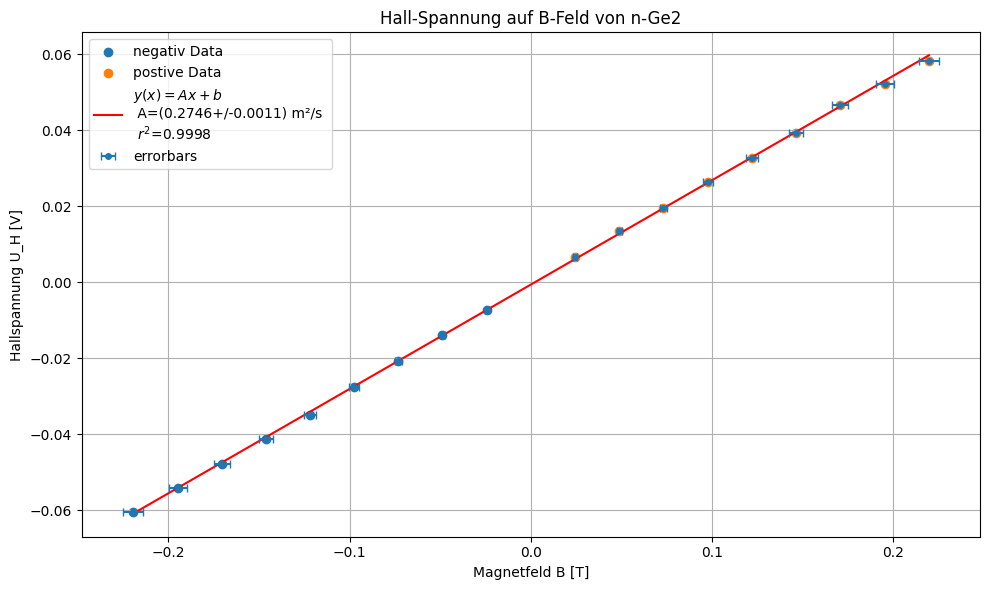

10985.54484+/-879.98999
568156533405188.00000+/-45511812944593.17969
(5.7+/-0.5)e+14


In [19]:
# Aufgabe 4
H_comb = np.concatenate([H_3, H_2])
U_comb = np.concatenate([U_H_3, U_H_2])
I_comb = np.concatenate([I_b_3, I_b_2])



U_H_u = ((np.absolute(U_comb*10**(3))*0.008 +0.3)*10**(-3))
H_comb_u = B(unp.uarray(I_comb,I_b_u),True)/1000
H_uu = unp.std_devs(H_comb_u)
print(H_comb)
print(I_comb)
print(H_comb_u)
# Fit
popt, pcov = curve_fit(Helper.linfit, H_comb, U_comb, p0=[1, 1], sigma = U_H_u, absolute_sigma= True)

a_opt, b_opt = popt
x_model = np.linspace(min(H_comb), max(H_comb), 100)
y_model = Helper.linfit(x_model, a_opt, b_opt)
perr = np.sqrt(np.diag(pcov))

A = ufloat(a_opt,perr[0])

print(f"{A:.4f}")

r2 = Helper.r2_curve_fit(popt, H_comb, U_comb, Helper.linfit)






# plot
plt.figure(figsize=(10, 6))
plt.scatter(H_3, U_H_3, label="negativ Data")
plt.scatter(H_2, U_H_2, label="postive Data")
plt.plot(x_model, y_model, color='r', label=f"$y(x)=Ax+b$ \n A=({A:.4f}) m²/s \n $r^2$={r2:.4f}")
plt.errorbar(H_comb, U_comb, fmt='o', xerr= H_uu, capsize=3, markersize=4, label="errorbars")
# plt.plot(x_model_1, y_model_1, color='r', label=f"$y(x)=Ax+b$\n $r^2$={r2:.4f}")
# plt.plot(V, p, "o")
plt.ylabel(r"Hallspannung U_H [V]")
plt.xlabel(r"Magnetfeld B [T]")
plt.legend()
plt.title("Hall-Spannung auf B-Feld von n-Ge2")
plt.tight_layout()
plt.grid()
plt.show()

R_H = (d*A/(I_v))*10**6
print(f"{R_H:.5f}")
n = 1/(c.elementary_charge*R_H)
print(f"{n:.5f}")
print(n)


[0.00812331 0.00812331 0.00812896 0.00813462 0.00814592 0.00815157
 0.00816853 0.00817984 0.0081968  0.00821376]
0.24912081717545506


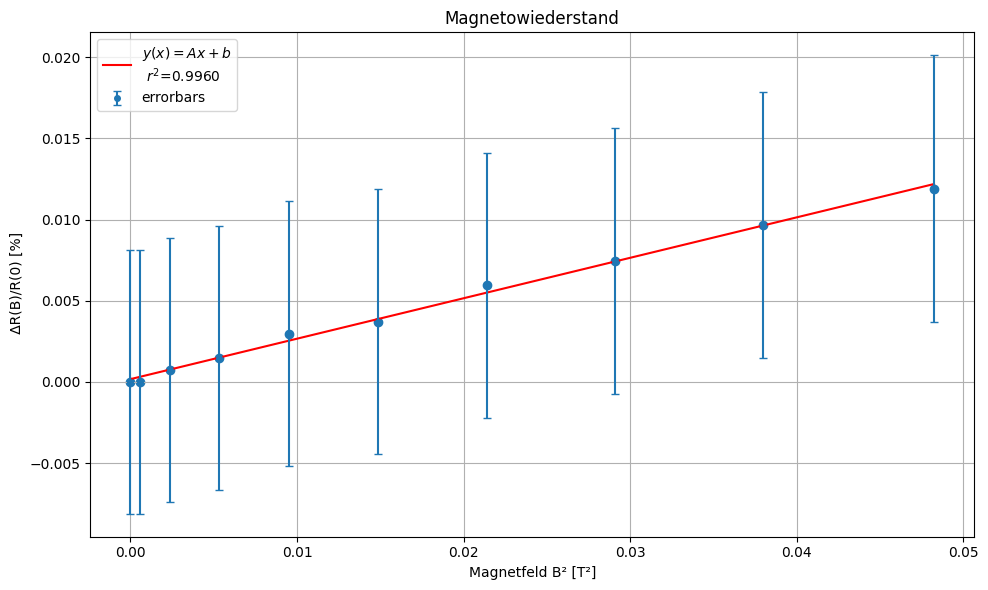

53.760+/-4.312
37.202+/-2.984
3372.450+/-24.601
(9.1+/-0.7)e+03
3211.857+/-23.429


In [28]:
# Aufgabe 5



# Data

U_R = np.array([1.344, 1.344, 1.345, 1.346, 1.348, 1.349, 1.352, 1.354, 1.357, 1.360]) # V gemessene Hall-Spannung
I_b_3 = np.array([0, 0.501, 1.002, 1.500, 2.002, 2.504, 3.003, 3.503, 4.000, 4.510]) # A angelegter Strom am Magneten
H_4 = (B(I_b_3)/1000)**2 # B in T


U_R_u = unp.uarray(U_R ,U_R*0.005 +0.001)


R_R_u = U_R_u/I_v

U_del = U_R-1.344
R_del_u = R_R_u- R_R_u[0]
Pro = U_del/1.344
Pro_u = R_del_u/R_R_u[0]
Pro_uu = unp.std_devs(Pro_u)
Pro_uu[0] = 0.00812331
print(Pro_uu)

# Fit
popt, pcov = curve_fit(Helper.linfit, H_4, Pro, p0=[1, 1])

a_opt, b_opt = popt
x_model = np.linspace(min(H_4), max(H_4), 100)
y_model = Helper.linfit(x_model, a_opt, b_opt)
perr = np.sqrt(np.diag(pcov))
print(a_opt)
r2 = Helper.r2_curve_fit(popt, H_4, Pro, Helper.linfit)

# def inverse(x):
#     return x**(1/2)


# def forward(x):
#     return x**2

# plot
plt.figure(figsize=(10, 6))
plt.scatter(H_4, Pro)
plt.plot(x_model, y_model, color='r', label=f"$y(x)=Ax+b$\n $r^2$={r2:.4f}")
plt.errorbar(H_4, Pro, fmt='o', yerr= Pro_uu, capsize=3, markersize=4, label="errorbars")
# plt.plot(V, p, "o")
# plt.xscale('function', functions=(forward, inverse))
plt.ylabel(r" ∆R(B)/R(0) [%]")
plt.xlabel(r"Magnetfeld B² [T²]")
plt.legend()
plt.title("Magnetowiederstand")
plt.tight_layout()
plt.grid()
plt.show()

# Rechnung

roh = (1/(R_R_u[0]*d*b/l))
print(f"{R_R_u[0]:.3f}")
print(f"{roh:.3f}")
miu = roh*R_H/100
print(f"{miu:.3f}")
print(R_H)
miu_k = miu/1.05
print(f"{miu_k:.3f}")

0.214613686972026
[-0.0243987 -0.0487974 -0.07305   -0.0976435 -0.1219448 -0.1462461
 -0.1705961 -0.1952383 -0.219637   0.0243987  0.0487974  0.07305
  0.0976435  0.1219448  0.1462461  0.1705961  0.1952383  0.219637 ]
[-0.501 -1.002 -1.5   -2.005 -2.504 -3.003 -3.503 -4.009 -4.51   0.501
  1.002  1.5    2.005  2.504  3.003  3.503  4.009  4.51 ]
[-0.024398700000000002+/-0.0011509646711241838
 -0.048797400000000005+/-0.0015661579411745167
 -0.07305000000000002+/-0.002078358005734335
 -0.09764350000000001+/-0.0026403372842120003
 -0.1219448+/-0.0032159389749832016
 -0.14624610000000002+/-0.003802530821911113
 -0.1705961+/-0.004396908820931361
 -0.19523830000000003+/-0.005002747447578781
 -0.219637+/-0.0056055085101710455
 0.024398700000000002+/-0.0011509646711241838
 0.048797400000000005+/-0.0015661579411745167
 0.07305000000000002+/-0.002078358005734335
 0.09764350000000001+/-0.0026403372842120003
 0.1219448+/-0.0032159389749832016
 0.14624610000000002+/-0.003802530821911113
 0.1705961+/

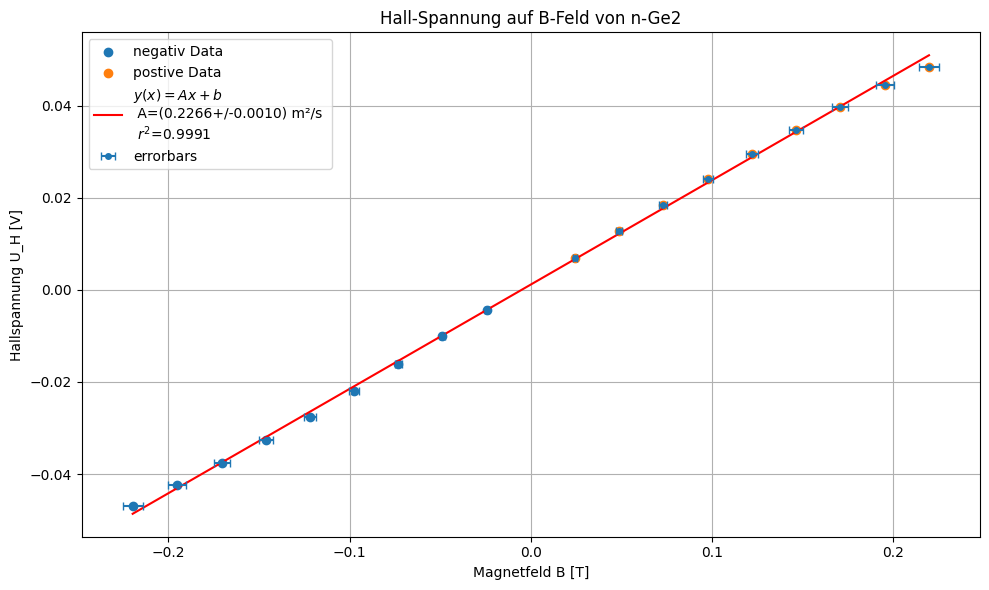

9065.14490+/-726.35613
688517298333277.50000+/-55168313730090.77344
(6.9+/-0.6)e+14


In [21]:
# Versuch 6

# gemessen
I_m = ufloat(3.130,0.030) # A
H = B(I_m, True)


# Data

U_H_2 = np.array([7, 12.7, 18.4, 24.1, 29.5, 34.7, 39.7, 44.5, 48.4])*10**(-3) # V gemessene Hall-Spannung
I_b_2 = np.array([0.501, 1.002, 1.500, 2.005, 2.504, 3.003, 3.503, 4.009, 4.510]) # A angelegter Strom am Magneten
H_2 = B(I_b_2)/1000 # B in T

# Fit
popt_1, pcov_1 = curve_fit(Helper.linfit, H_2, U_H_2, p0=[1, 1])

a_opt, b_opt = popt_1
x_model_1 = np.linspace(min(H_2), max(H_2), 100)
y_model_1 = Helper.linfit(x_model_1, a_opt, b_opt)
perr = np.sqrt(np.diag(pcov))
print(a_opt)
r2 = Helper.r2_curve_fit(popt_1, H_2, U_H_2, Helper.linfit)


# # plot
# plt.figure(figsize=(10, 6))
# plt.scatter(H_2, U_H_2)
# plt.plot(x_model_1, y_model_1, color='r', label=f"$y(x)=Ax+b$\n $r^2$={r2:.4f}")
# # plt.plot(V, p, "o")
# plt.ylabel(r"Hallspannung U_H [V]")
# plt.xlabel(r"Magnetfeld B [T]")
# plt.legend()
# plt.title("Hall-Spannung von p-Ge2")
# plt.tight_layout()
# plt.grid()
# plt.show()


# Versuch 6.2

# gemessen
I_m = ufloat(3.130,0.030) # A
H = B(I_m, True)


# Data

U_H_3 = -np.array([4.3, 10, 16, 21.9, 27.6, 32.6, 37.7, 42.4, 46.9])*10**(-3) # V gemessene Hall-Spannung
I_b_3 = -np.array([0.501, 1.002, 1.500, 2.005, 2.504, 3.003, 3.503, 4.009, 4.510]) # A angelegter Strom am Magneten
U_hs = np.array([1.284, 1.285, 1.287, 1.29, 1.293, 1.298, 1.302, 1.307, 1.311]) # kp warum V ergibt keinen Sinn
H_3 = B(I_b_3)/1000 # B in T

# Fit
H_comb = np.concatenate([H_3, H_2])
U_comb = np.concatenate([U_H_3, U_H_2])
I_comb = np.concatenate([I_b_3, I_b_2])



U_H_u = ((np.absolute(U_comb*10**(3))*0.008 +0.3)*10**(-3))
H_comb_u = B(unp.uarray(I_comb,I_b_u),True)/1000
H_uu = unp.std_devs(H_comb_u)
print(H_comb)
print(I_comb)
print(H_comb_u)
# Fit
popt, pcov = curve_fit(Helper.linfit, H_comb, U_comb, p0=[1, 1], sigma = U_H_u, absolute_sigma= True)

a_opt, b_opt = popt
x_model = np.linspace(min(H_comb), max(H_comb), 100)
y_model = Helper.linfit(x_model, a_opt, b_opt)
perr = np.sqrt(np.diag(pcov))

A = ufloat(a_opt,perr[0])

print(f"{A:.4f}")

r2 = Helper.r2_curve_fit(popt, H_comb, U_comb, Helper.linfit)


# plot
# plt.figure(figsize=(10, 6))
# plt.scatter(H_2, U_H_2)
# plt.plot(x_model_1, y_model_1, color='r', label=f"$y(x)=Ax+b$\n $r^2$={r2:.4f}")
# plt.errorbar(H_4, Pro, fmt='o', yerr= Pro_uu, capsize=3, markersize=4, label="errorbars")
# # plt.plot(V, p, "o")
# plt.ylabel(r"Hallspannung U_H [V]")
# plt.xlabel(r"Magnetfeld B [T]")
# plt.legend()
# plt.title("Hall-Spannung von p-Ge2")
# plt.tight_layout()
# plt.grid()
# plt.show()

# plot
plt.figure(figsize=(10, 6))
plt.scatter(H_3, U_H_3, label="negativ Data")
plt.scatter(H_2, U_H_2, label="postive Data")
plt.plot(x_model, y_model, color='r', label=f"$y(x)=Ax+b$ \n A=({A:.4f}) m²/s \n $r^2$={r2:.4f}")
plt.errorbar(H_comb, U_comb, fmt='o', xerr= H_uu, capsize=3, markersize=4, label="errorbars")
# plt.plot(x_model_1, y_model_1, color='r', label=f"$y(x)=Ax+b$\n $r^2$={r2:.4f}")
# plt.plot(V, p, "o")
plt.ylabel(r"Hallspannung U_H [V]")
plt.xlabel(r"Magnetfeld B [T]")
plt.legend()
plt.title("Hall-Spannung auf B-Feld von n-Ge2")
plt.tight_layout()
plt.grid()
plt.show()

R_H = (d*A/(I_v))*10**6
print(f"{R_H:.5f}")
n = 1/(c.elementary_charge*R_H)
print(f"{n:.5f}")
print(n)


[0.00817248 0.00817248 0.00817842 0.00819029 0.0082081  0.0082259
 0.00825559 0.00827933 0.00830901 0.00833276]
0.45745276150768


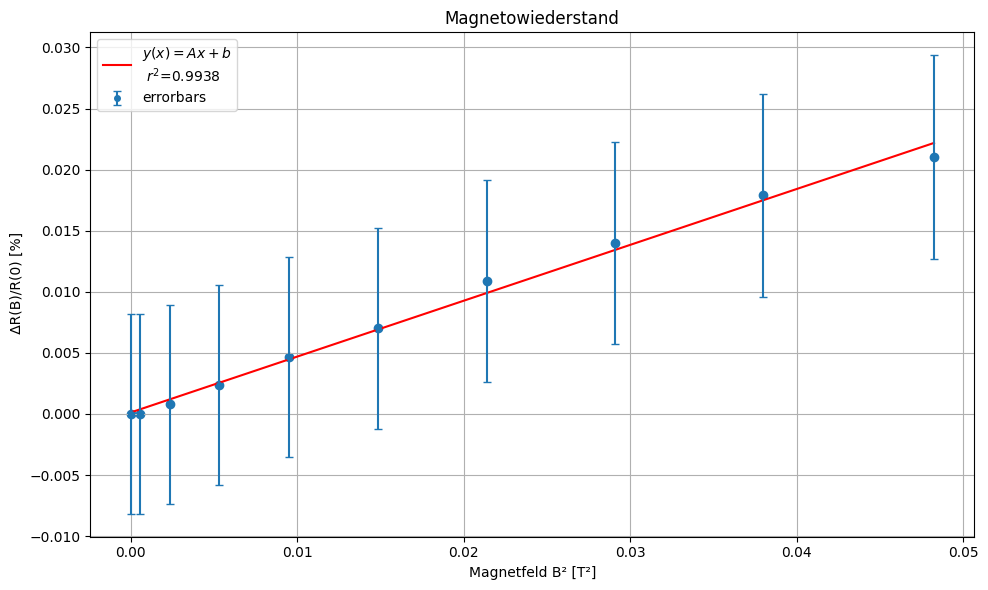

[0.0+/-0 0.0+/-0.4197385853123346
 0.03999999999999204+/-0.41989222426713263
 0.11999999999999744+/-0.4202727209800798
 0.240000000000002+/-0.42102598494629756
 0.3599999999999923+/-0.42199720378220507
 0.5600000000000023+/-0.4240960268618418
 0.7199999999999989+/-0.4262020178272271
 0.9199999999999946+/-0.42935901061931836
 1.0799999999999983+/-0.4322962410199746]
51.360+/-4.120
38.941+/-3.123
mu =3530.041+/-25.847
(9.1+/-0.7)e+03
1961.134+/-14.359


In [33]:
# Magnetowiederstand
U_R = np.array([1.284, 1.284, 1.285, 1.287, 1.29, 1.293, 1.298, 1.302, 1.307, 1.311]) # V gemessene Spannung
I_b_3 = np.array([0, 0.501, 1.002, 1.500, 2.002, 2.504, 3.003, 3.503, 4.000, 4.510]) # A angelegter Strom am Magneten
H_4 = (B(I_b_3)/1000)**2 # B² in T²


U_R_u = unp.uarray(U_R ,U_R*0.005 +0.001)


R_R_u = U_R_u/I_v

U_del = U_R-1.284
R_del_u = R_R_u- R_R_u[0]
Pro = U_del/1.284
Pro_u = R_del_u/R_R_u[0]
Pro_uu = unp.std_devs(Pro_u)
Pro_uu[0] = 0.00817248
print(Pro_uu)
# Fit
popt, pcov = curve_fit(Helper.linfit, H_4, Pro, p0=[1, 1])

a_opt, b_opt = popt
x_model = np.linspace(min(H_4), max(H_4), 100)
y_model = Helper.linfit(x_model, a_opt, b_opt)
perr = np.sqrt(np.diag(pcov))
print(a_opt)
r2 = Helper.r2_curve_fit(popt, H_4, Pro, Helper.linfit)

# def inverse(x):
#     return x**(1/2)


# def forward(x):
#     return x**2

# plot
plt.figure(figsize=(10, 6))
plt.scatter(H_4, Pro)
plt.plot(x_model, y_model, color='r', label=f"$y(x)=Ax+b$\n $r^2$={r2:.4f}")
plt.errorbar(H_4, Pro, fmt='o', yerr= Pro_uu, capsize=3, markersize=4, label="errorbars")
# plt.plot(V, p, "o")
# plt.xscale('function', functions=(forward, inverse))
plt.ylabel(r" ∆R(B)/R(0) [%]")
plt.xlabel(r"Magnetfeld B² [T²]")
plt.legend()
plt.title("Magnetowiederstand")
plt.tight_layout()
plt.grid()
plt.show()

# Rechnung

print(R_del_u)
roh = (1/(R_R_u[0]*d*b/l))
print(f"{R_R_u[0]:.3f}")
print(f"{roh:.3f}")
miu = roh*R_H/100
print(f"mu ={miu:.3f}")
print(R_H)
miu_k = miu/1.8
print(f"{miu_k:.3f}")



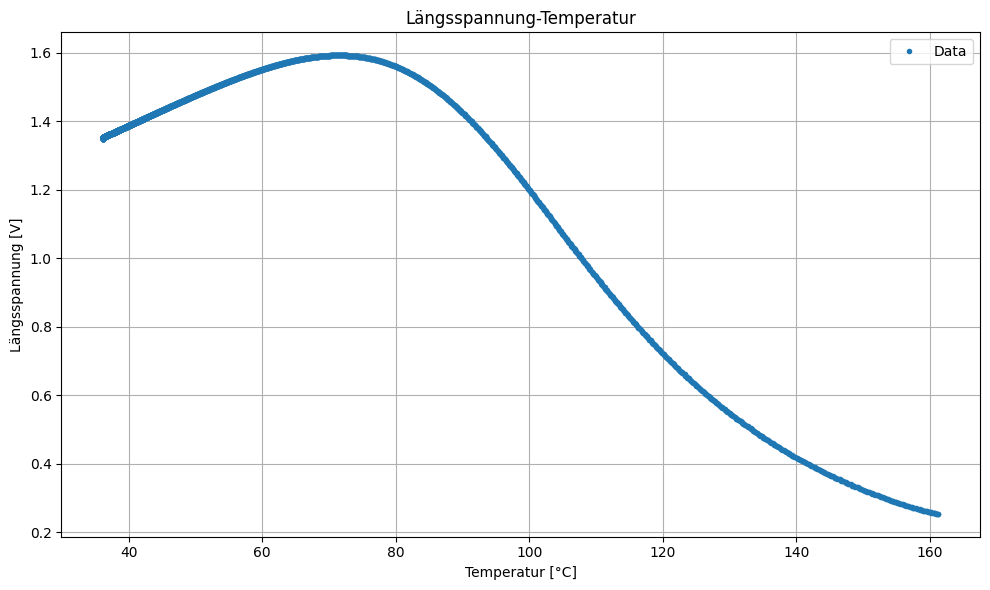

In [23]:
# csv-plots

Data = pd.read_csv("test.csv", sep=',', decimal='.')   # read csv für den Graphen


T = Data["T"].to_numpy()    # Temperatur Data

U = Data["U"].to_numpy()    # Spannung Data


plt.figure(figsize=(10, 6))
# plt.scatter(E, N)
# plt.fill(T, U, color="C0", alpha=0.25, label="eingeschlossene Fläche")
plt.plot(T, U, '.', linewidth=1, label="Data")
plt.xlabel("Temperatur [°C]")
plt.ylabel("Längsspannung [V]")
plt.title("Längsspannung-Temperatur")
plt.legend()
plt.grid()
plt.tight_layout()

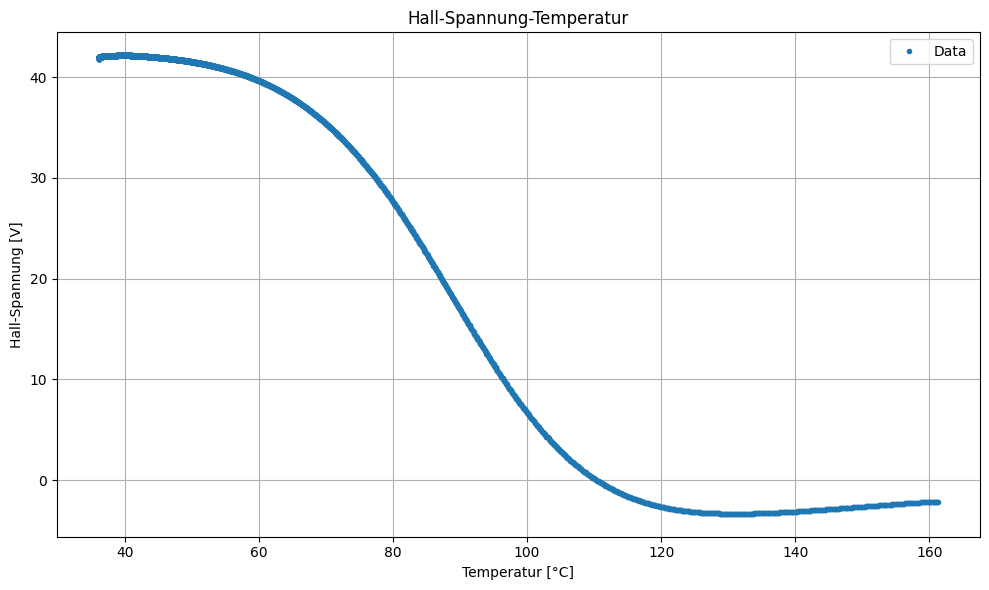

In [24]:
T = Data["T"].to_numpy()    # Temperatur Data

U_H = Data["U_H"].to_numpy()    # Spannung Data


plt.figure(figsize=(10, 6))
# plt.scatter(E, N)
# plt.fill(T, U, color="C0", alpha=0.25, label="eingeschlossene Fläche")
plt.plot(T, U_H, '.', linewidth=1, label="Data")
plt.xlabel("Temperatur [°C]")
plt.ylabel("Hall-Spannung [V]")
plt.title("Hall-Spannung-Temperatur")
plt.legend()
plt.grid()
plt.tight_layout()

<>:9: SyntaxWarning: invalid escape sequence '\O'
<>:9: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_1035/1301859708.py:9: SyntaxWarning: invalid escape sequence '\O'
  plt.ylabel(f"Widerstand [$\Omega$]")


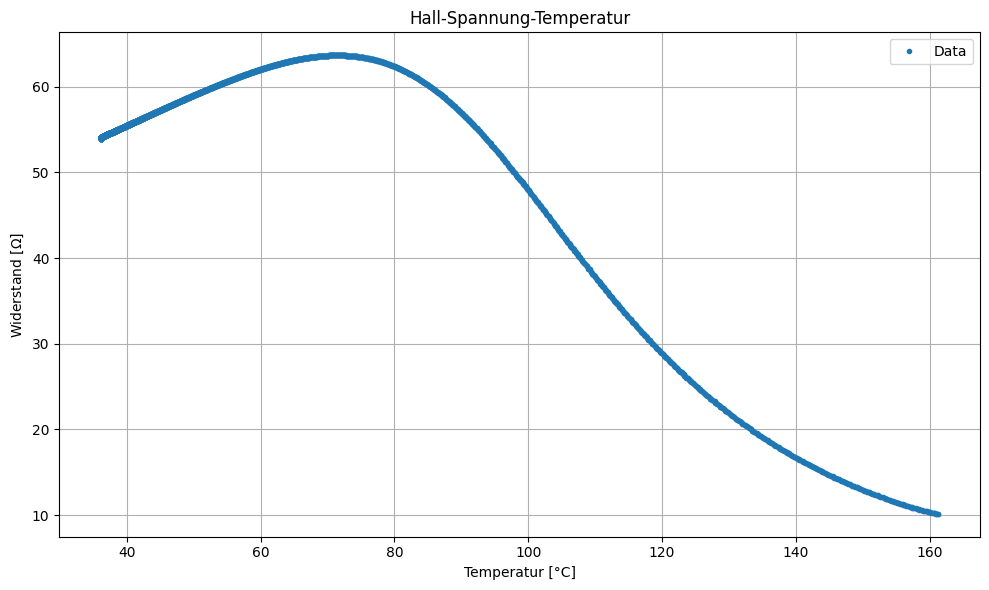

In [ ]:
R = U/0.025


plt.figure(figsize=(10, 6))
# plt.scatter(E, N)
# plt.fill(T, U, color="C0", alpha=0.25, label="eingeschlossene Fläche")
plt.plot(T, R, '.', linewidth=1, label="Data")
plt.xlabel("Temperatur [°C]")
plt.ylabel(f"Widerstand [$\Omega$]")
plt.title("Widerstand-Temperatur")
plt.legend()
plt.grid()
plt.tight_layout()

In [25]:
# # Hall-Spannung

# # known
# l = 20 #mm Länge der Proben
# b = 10 #mm Breite der Probe
# d = 1 #mm Dicke der Probe
# d_p = ufloat(10.0, 0.2) #mm Abstabd der Polschuhe
# I_n = 0.025 # A angelegter Strom
# I_n_u = 0.001 # Unsicherheit
# def B(I_b, u = False): 
#     '''
#     Magnetfeld in Abhängigkeit der angelegten Spannung

#     Input : I_b [A]

#     Outbput : B [mT]
#     '''    

#     if u:
#         B = ufloat(48.70,0.25)*I_b
#     else:
#         B = 48.70*I_b
#     return B


# # Versuch 1

# # gemessen
# I_m = ufloat(3.130,0.030) # A
# H = B(I_m, True)


# # Data

# U_H = np.array([40.8, 7.8, 12.2, 19.2, 28.7, 34.9, 43.9])*10**(-3) # V gemessene Hall-Spannung
# I = np.array([0.025, 0.004, 0.007, 0.011, 0.017, 0.022, 0.027]) # A angelegter Strom
# U_H_u = U_H*0.008 +0.0003
# I_u = 0.002 


# # Fit
# popt, pcov = curve_fit(Helper.linfit, I, U_H, p0=[1, 1])

# a_opt, b_opt = popt
# x_model = np.linspace(min(I), max(I), 100)
# y_model = Helper.linfit(x_model, a_opt, b_opt)
# perr = np.sqrt(np.diag(pcov))
# print(a_opt)
# r2 = Helper.r2_curve_fit(popt, I, U_H, Helper.linfit)


# # plot
# plt.figure(figsize=(10, 6))
# plt.scatter(I, U_H)
# plt.plot(x_model, y_model, color='r', label=f"$y(x)=Ax+b$\n $r^2$={r2:.4f}")
# plt.errorbar(I, U_H, fmt='o',xerr=I_u, yerr=U_H_u, capsize=3, markersize=4)
# # plt.plot(V, p, "o")
# plt.ylabel(r"Hallspannung U_H [V]")
# plt.xlabel(r"Angelegter Strom [A]")
# plt.legend()
# plt.title("Hall-Spannung von n-Ge2")
# plt.tight_layout()
# plt.grid()
# plt.show()




# # Versuch 2

# # gemessen
# I_m = ufloat(3.130,0.030) # A
# H = B(I_m, True)


# # Data

# U_H_2 = np.array([6.7, 13.4, 19.5, 26.4, 32.8, 39.3, 46.6, 52.2, 58.1])*10**(-3) # V gemessene Hall-Spannung
# I_b = np.array([0.501, 1.002, 1.500, 2.005, 2.504, 3.003, 3.503, 4.009, 4.510]) # A angelegter Strom am Magneten
# H_2 = B(I_b)/1000 # B in T

# U_H_u = U_H_2*0.008 +0.0003
# I_b_u = 0.02 
# H_2_u = B(unp.uarray(I_b,I_b_u),True)/1000
# print(H_2_u)
# test = unp.std_devs(H_2_u)
# print(test)
# # Fit
# popt_1, pcov_1 = curve_fit(Helper.linfit, H_2, U_H_2, p0=[1, 1])

# a_opt, b_opt = popt_1
# x_model_1 = np.linspace(min(H_2), max(H_2), 100)
# y_model_1 = Helper.linfit(x_model_1, a_opt, b_opt)
# perr = np.sqrt(np.diag(pcov))
# print(a_opt)
# r2 = Helper.r2_curve_fit(popt_1, H_2, U_H_2, Helper.linfit)


# # plot
# plt.figure(figsize=(10, 6))
# plt.scatter(H_2, U_H_2)
# plt.plot(x_model_1, y_model_1, color='r', label=f"$y(x)=Ax+b$\n $r^2$={r2:.4f}")
# # plt.plot(V, p, "o")
# plt.errorbar(H_2, U_H_2, fmt='o',xerr=test, yerr=U_H_u, capsize=3, markersize=4)
# plt.ylabel(r"Hallspannung U_H [V]")
# plt.xlabel(r"Magnetfeld B [T]")
# plt.legend()
# plt.title("Hall-Spannung von n-Ge2")
# plt.tight_layout()
# plt.grid()
# plt.show()





# # Versuch 3


# # Data

# U_H_3 = -np.array([7.2, 13.8, 20.8, 27.6, 34.9, 41.3, 47.9, 54.2, 60.4])*10**(-3) # V gemessene Hall-Spannung
# I_b_3 = -np.array([0.501, 1.002, 1.500, 2.002, 2.504, 3.003, 3.503, 4.000, 4.510]) # A angelegter Strom am Magneten
# H_3 = B(I_b_3)/1000 # B in T

# # Fit
# popt, pcov = curve_fit(Helper.linfit, H_3, U_H_3, p0=[1, 1])

# a_opt, b_opt = popt
# x_model = np.linspace(min(H_3), max(H_3), 100)
# y_model = Helper.linfit(x_model, a_opt, b_opt)
# perr = np.sqrt(np.diag(pcov))
# print(a_opt)
# r2 = Helper.r2_curve_fit(popt, H_3, U_H_3, Helper.linfit)


# # plot
# plt.figure(figsize=(10, 6))
# plt.scatter(H_3, U_H_3)
# plt.plot(x_model, y_model, color='r', label=f"$y(x)=Ax+b$\n $r^2$={r2:.4f}")
# # plt.plot(V, p, "o")
# plt.ylabel(r"Hallspannung U_H [V]")
# plt.xlabel(r"Magnetfeld B [T]")
# plt.legend()
# plt.title("Hall-Spannung von n-Ge2")
# plt.tight_layout()
# plt.grid()
# plt.show()

# # Aufgabe 4
# H_comb = np.concatenate([H_3, H_2])
# U_comb = np.concatenate([U_H_3, U_H_2])

# # Fit
# popt, pcov = curve_fit(Helper.linfit, H_comb, U_comb, p0=[1, 1])

# a_opt, b_opt = popt
# x_model = np.linspace(min(H_comb), max(H_comb), 100)
# y_model = Helper.linfit(x_model, a_opt, b_opt)
# perr = np.sqrt(np.diag(pcov))
# print(a_opt)
# r2 = Helper.r2_curve_fit(popt, H_comb, U_comb, Helper.linfit)






# # plot
# plt.figure(figsize=(10, 6))
# plt.scatter(H_3, U_H_3)
# plt.scatter(H_2, U_H_2)
# plt.plot(x_model, y_model, color='r', label=f"$y(x)=Ax+b$\n $r^2$={r2:.4f}")
# # plt.plot(x_model_1, y_model_1, color='r', label=f"$y(x)=Ax+b$\n $r^2$={r2:.4f}")
# # plt.plot(V, p, "o")
# plt.ylabel(r"Hallspannung U_H [V]")
# plt.xlabel(r"Magnetfeld B [T]")
# plt.legend()
# plt.title("Hall-Spannung von n-Ge2")
# plt.tight_layout()
# plt.grid()
# plt.show()


# # Aufgabe 5



# # Data

# U_R = np.array([1.344, 1.344, 1.345, 1.346, 1.348, 1.349, 1.352, 1.354, 1.357, 1.360]) # V gemessene Hall-Spannung
# I_b_3 = np.array([0, 0.501, 1.002, 1.500, 2.002, 2.504, 3.003, 3.503, 4.000, 4.510]) # A angelegter Strom am Magneten
# H_4 = (B(I_b_3)/1000)**2 # B in T
# U_del = U_R-1.344

# Pro = U_del/1.344

# # Fit
# popt, pcov = curve_fit(Helper.linfit, H_4, Pro, p0=[1, 1])

# a_opt, b_opt = popt
# x_model = np.linspace(min(H_4), max(H_4), 100)
# y_model = Helper.linfit(x_model, a_opt, b_opt)
# perr = np.sqrt(np.diag(pcov))
# print(a_opt)
# r2 = Helper.r2_curve_fit(popt, H_4, Pro, Helper.linfit)

# # def inverse(x):
# #     return x**(1/2)


# # def forward(x):
# #     return x**2

# # plot
# plt.figure(figsize=(10, 6))
# plt.scatter(H_4, Pro)
# plt.plot(x_model, y_model, color='r', label=f"$y(x)=Ax+b$\n $r^2$={r2:.4f}")
# # plt.plot(V, p, "o")
# # plt.xscale('function', functions=(forward, inverse))
# plt.ylabel(r" ∆R(B)/R(0) [%]")
# plt.xlabel(r"Magnetfeld B² [T²]")
# # plt.legend()
# plt.title("Magnetowiederstand")
# plt.tight_layout()
# plt.grid()
# plt.show()








# # Versuch 6

# # gemessen
# I_m = ufloat(3.130,0.030) # A
# H = B(I_m, True)


# # Data

# U_H_2 = np.array([7, 12.7, 18.4, 24.1, 29.5, 34.7, 39.7, 44.5, 48.4])*10**(-3) # V gemessene Hall-Spannung
# I_b = np.array([0.501, 1.002, 1.500, 2.005, 2.504, 3.003, 3.503, 4.009, 4.510]) # A angelegter Strom am Magneten
# H_2 = B(I_b)/1000 # B in T

# # Fit
# popt_1, pcov_1 = curve_fit(Helper.linfit, H_2, U_H_2, p0=[1, 1])

# a_opt, b_opt = popt_1
# x_model_1 = np.linspace(min(H_2), max(H_2), 100)
# y_model_1 = Helper.linfit(x_model_1, a_opt, b_opt)
# perr = np.sqrt(np.diag(pcov))
# print(a_opt)
# r2 = Helper.r2_curve_fit(popt_1, H_2, U_H_2, Helper.linfit)


# # plot
# plt.figure(figsize=(10, 6))
# plt.scatter(H_2, U_H_2)
# plt.plot(x_model_1, y_model_1, color='r', label=f"$y(x)=Ax+b$\n $r^2$={r2:.4f}")
# # plt.plot(V, p, "o")
# plt.ylabel(r"Hallspannung U_H [V]")
# plt.xlabel(r"Magnetfeld B [T]")
# plt.legend()
# plt.title("Hall-Spannung von p-Ge2")
# plt.tight_layout()
# plt.grid()
# plt.show()


# # Versuch 6.2

# # gemessen
# I_m = ufloat(3.130,0.030) # A
# H = B(I_m, True)


# # Data

# U_H_2 = -np.array([4.3, 10, 16, 21.9, 27.6, 32.6, 37.7, 42.4, 46.9])*10**(-3) # V gemessene Hall-Spannung
# I_b = -np.array([0.501, 1.002, 1.500, 2.005, 2.504, 3.003, 3.503, 4.009, 4.510]) # A angelegter Strom am Magneten
# U_hs = np.array([1.284, 1.285, 1.287, 1.29, 1.293, 1.298, 1.302, 1.307, 1.311]) # kp warum V ergibt keinen Sinn
# H_2 = B(I_b)/1000 # B in T

# # Fit
# popt_1, pcov_1 = curve_fit(Helper.linfit, H_2, U_H_2, p0=[1, 1])

# a_opt, b_opt = popt_1
# x_model_1 = np.linspace(min(H_2), max(H_2), 100)
# y_model_1 = Helper.linfit(x_model_1, a_opt, b_opt)
# perr = np.sqrt(np.diag(pcov))
# print(a_opt)
# r2 = Helper.r2_curve_fit(popt_1, H_2, U_H_2, Helper.linfit)


# # plot
# plt.figure(figsize=(10, 6))
# plt.scatter(H_2, U_H_2)
# plt.plot(x_model_1, y_model_1, color='r', label=f"$y(x)=Ax+b$\n $r^2$={r2:.4f}")
# # plt.plot(V, p, "o")
# plt.ylabel(r"Hallspannung U_H [V]")
# plt.xlabel(r"Magnetfeld B [T]")
# plt.legend()
# plt.title("Hall-Spannung von p-Ge2")
# plt.tight_layout()
# plt.grid()
# plt.show()